# 01 Load and Visualize SDSU Midwest Flood Dataset 2019

This notebook shows how to load the **SDSU Midwest Flood Dataset 2019** from Hugging Face, inspect the dataset schema, visualize image-mask pairs, and create a simple mask overlay.

Dataset: https://huggingface.co/datasets/youngsun05/SDSU_MidWest_Flood_2019

GitHub: https://github.com/youngsunjang/SDSU_MidWest_Flood_2019


## 1. Install and import packages

If you are running this notebook in Google Colab, run the installation cell below first.


In [1]:
!pip install -q datasets matplotlib pillow numpy

In [2]:
from datasets import load_dataset
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image


## 2. Load the dataset from Hugging Face

The corrected Hugging Face dataset contains explicit `image` and `mask` columns. Each row is one image-mask pair.


In [3]:
dataset_name = "youngsun05/SDSU_MidWest_Flood_2019"

ds = load_dataset(dataset_name)

print(ds)
print(ds["train"].features)
print(ds["train"][0].keys())


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/3.38k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/268M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/500 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'mask', 'file_name', 'mask_file_name'],
        num_rows: 500
    })
})
{'image': Image(mode=None, decode=True), 'mask': Image(mode=None, decode=True), 'file_name': Value('string'), 'mask_file_name': Value('string')}
dict_keys(['image', 'mask', 'file_name', 'mask_file_name'])


Expected structure:

```text
DatasetDict({
    train: Dataset({
        features: ['image', 'mask', 'file_name', 'mask_file_name'],
        num_rows: 500
    })
})
```


## 3. Inspect one sample

In this dataset, white pixels in the mask indicate flooded areas, and black pixels indicate non-flooded/background areas.


In [4]:
sample = ds["train"][1]

image = sample["image"]
mask = sample["mask"]

print("file_name:", sample["file_name"])
print("mask_file_name:", sample["mask_file_name"])
print("image:", type(image), image.mode, image.size)
print("mask:", type(mask), mask.mode, mask.size)


file_name: anomaly-1-IA_10.png
mask_file_name: label_anomaly-1-IA_10.png
image: <class 'PIL.PngImagePlugin.PngImageFile'> RGB (700, 700)
mask: <class 'PIL.PngImagePlugin.PngImageFile'> L (700, 700)


## 4. Check mask values

The original mask uses `0` for non-flooded/background pixels and `255` for flooded pixels.


In [5]:
mask_array = np.array(mask.convert("L"))

print("Mask shape:", mask_array.shape)
print("Mask dtype:", mask_array.dtype)
print("Unique values:", np.unique(mask_array))


Mask shape: (700, 700)
Mask dtype: uint8
Unique values: [  0 255]


For many segmentation models, it is convenient to convert the mask to binary values `0` and `1`.

Here, `1` means flooded area.


In [6]:
# In this dataset, white pixels indicate flooded areas.
binary_mask = (mask_array > 0).astype(np.uint8)

print("Binary mask shape:", binary_mask.shape)
print("Binary mask dtype:", binary_mask.dtype)
print("Binary mask unique values:", np.unique(binary_mask))


Binary mask shape: (700, 700)
Binary mask dtype: uint8
Binary mask unique values: [0 1]


## 5. Visualize image and mask

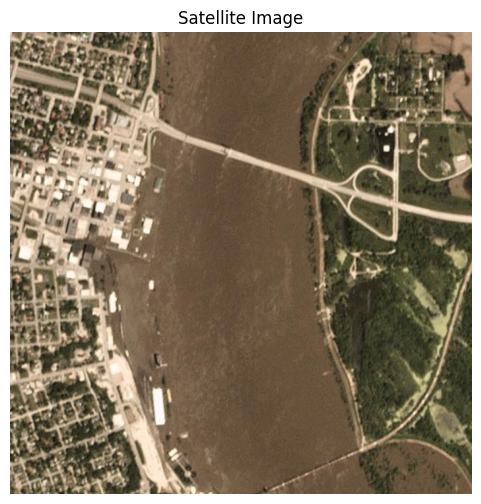

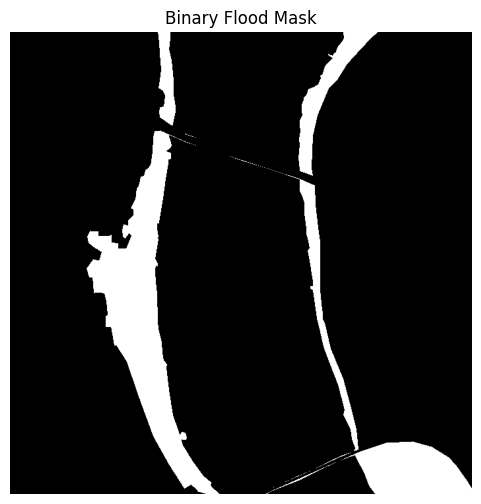

In [7]:
plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.title("Satellite Image")
plt.axis("off")
plt.show()

plt.figure(figsize=(6, 6))
plt.imshow(binary_mask, cmap="gray")
plt.title("Binary Flood Mask")
plt.axis("off")
plt.show()


## 6. Create a simple image-mask overlay

The overlay helps visually inspect whether the flood mask is aligned with the satellite image.


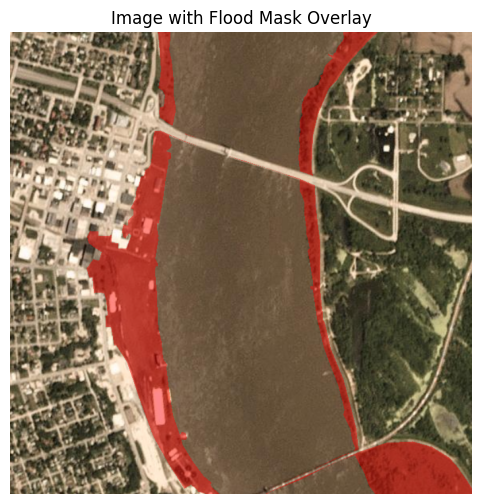

In [8]:
image_array = np.array(image.convert("RGB")).astype(np.float32) / 255.0

# Create a red overlay for flooded pixels.
overlay = image_array.copy()
overlay[binary_mask == 1] = [1.0, 0.0, 0.0]

alpha = 0.45
blended = (1 - alpha) * image_array + alpha * overlay

plt.figure(figsize=(6, 6))
plt.imshow(blended)
plt.title("Image with Flood Mask Overlay")
plt.axis("off")
plt.show()


## 7. Visualize several samples

This section displays several image-mask-overlay examples from the training split.


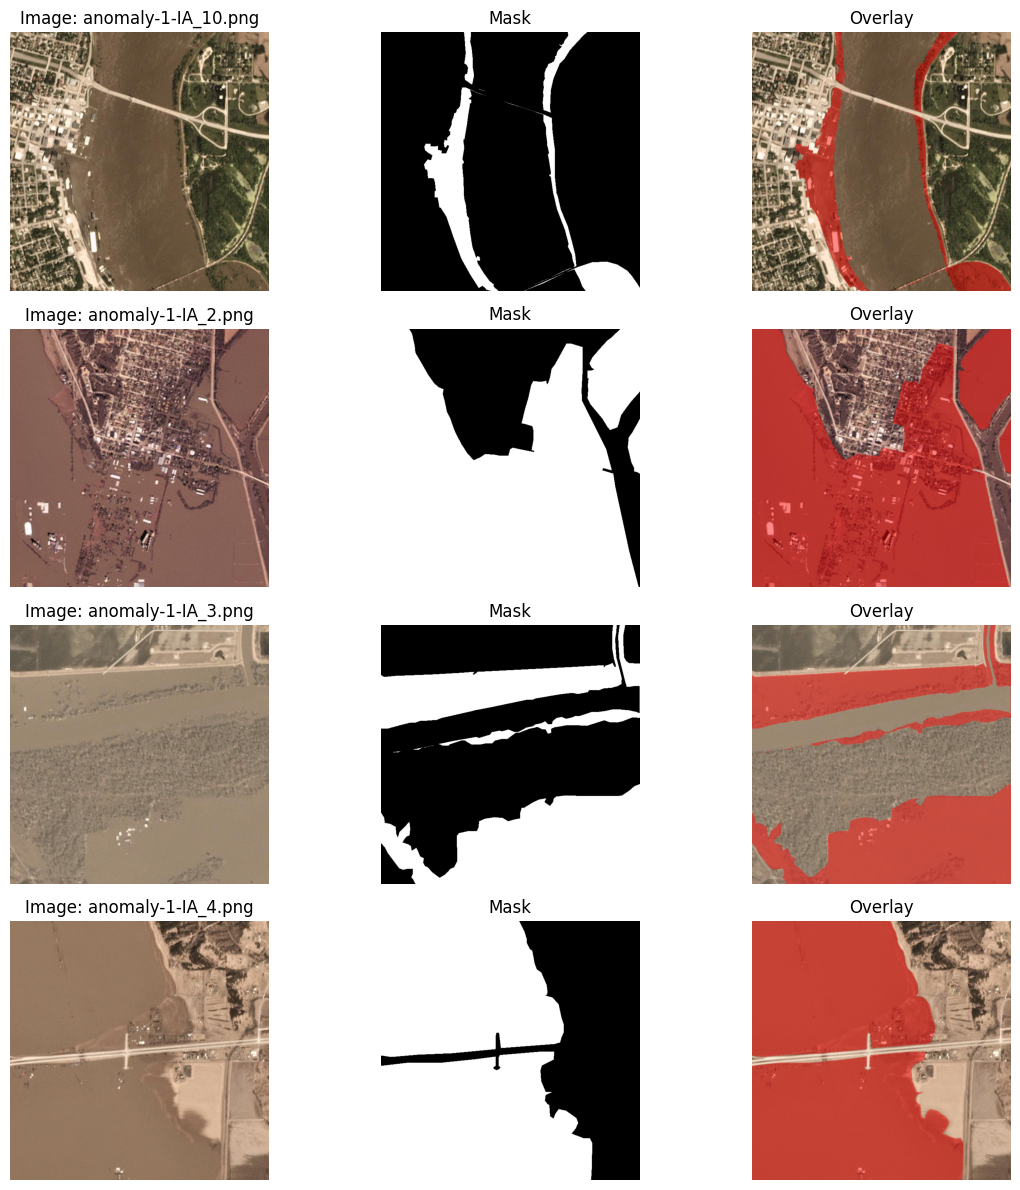

In [9]:
def make_overlay(image, mask, alpha=0.45):
    image_array = np.array(image.convert("RGB")).astype(np.float32) / 255.0
    mask_array = np.array(mask.convert("L"))

    # White pixels indicate flooded areas.
    binary_mask = (mask_array > 0).astype(np.uint8)

    overlay = image_array.copy()
    overlay[binary_mask == 1] = [1.0, 0.0, 0.0]

    blended = (1 - alpha) * image_array + alpha * overlay
    return blended


sample_indices = [1, 2, 3, 4]

plt.figure(figsize=(12, 12))

for row, idx in enumerate(sample_indices):
    sample = ds["train"][idx]
    image = sample["image"]
    mask = sample["mask"]
    overlay = make_overlay(image, mask)

    plt.subplot(len(sample_indices), 3, 3 * row + 1)
    plt.imshow(image)
    plt.title(f"Image: {sample['file_name']}")
    plt.axis("off")

    plt.subplot(len(sample_indices), 3, 3 * row + 2)
    plt.imshow(mask.convert("L"), cmap="gray")
    plt.title("Mask")
    plt.axis("off")

    plt.subplot(len(sample_indices), 3, 3 * row + 3)
    plt.imshow(overlay)
    plt.title("Overlay")
    plt.axis("off")

plt.tight_layout()
plt.show()


## 8. Optional: prepare a simple preprocessing pattern

The example below shows the basic preprocessing logic that many segmentation pipelines need. It does not require PyTorch, but it gives the expected image/mask array formats.


In [10]:
def preprocess_sample(sample, size=(256, 256)):
    image = sample["image"].convert("RGB")
    mask = sample["mask"].convert("L")

    image = image.resize(size)
    mask = mask.resize(size, resample=Image.NEAREST)

    image_array = np.array(image).astype(np.float32) / 255.0
    mask_array = np.array(mask)

    # White pixels indicate flooded areas.
    mask_array = (mask_array > 0).astype(np.uint8)

    return image_array, mask_array


image_array, mask_array = preprocess_sample(ds["train"][0])

print("Image array:", image_array.shape, image_array.dtype, image_array.min(), image_array.max())
print("Mask array:", mask_array.shape, mask_array.dtype, np.unique(mask_array))


Image array: (256, 256, 3) float32 0.09019608 1.0
Mask array: (256, 256) uint8 [0 1]


## Citation

If you use this dataset, please cite:

```bibtex
@misc{jang2024midwestflood,
  title={A Novel Dataset for Flood Detection Robust to Seasonal Changes in Satellite Imagery},
  author={Youngsun Jang and Dongyoun Kim and Chulwoo Pack and Kwanghee Won},
  year={2024},
  note={Presented at ACM RACS 2024. Available at \url{https://github.com/youngsunjang/SDSU_MidWest_Flood_2019}, \url{https://huggingface.co/datasets/youngsun05/SDSU_MidWest_Flood_2019}, and \url{https://arxiv.org/abs/2507.23193}},
}
```
